# Ensemble Methods

## Overview

**Ensemble methods** combine multiple machine learning models to produce predictions that are more accurate and robust than any individual model. The key insight is that a group of weak or moderately accurate learners, when combined correctly, can form a strong learner.

This notebook covers two families of ensemble techniques:

1. **Bagging** — parallel ensembles that reduce variance via bootstrap sampling.
2. **Voting** — diverse ensembles that leverage the complementary strengths of different model types.

---

## Why Ensembles Work

A single model's error can be decomposed as:

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

- **Bagging** targets **variance** — averaging uncorrelated predictions smooths out individual errors.
- **Boosting** (not implemented here) targets **bias** — sequentially correcting mistakes.
- **Voting** targets both by combining fundamentally different model types.

If $B$ independent models each have error $\epsilon$ with zero mean and variance $\sigma^2$, their average has variance $\sigma^2 / B$. Real models are not fully independent, so gains are smaller — but still significant.

---

## Bagging (Bootstrap Aggregating)

Each estimator is trained on a **bootstrap sample** — $n$ samples drawn with replacement from the training set. Approximately 63.2% of samples appear in each bootstrap; the remaining 36.8% form the natural out-of-bag validation set.

**Aggregation:**
- Classification → **majority vote**: $\hat{y} = \text{mode}\{h_1(\mathbf{x}), \dots, h_B(\mathbf{x})\}$
- Regression → **mean**: $\hat{y} = \frac{1}{B}\sum_{b=1}^{B} h_b(\mathbf{x})$

Bagging is most effective with **high-variance base learners** (e.g. deep decision trees) where small changes in training data lead to very different models.

---

## Voting Classifier

The **Voting Classifier** combines several *different* models trained on the full dataset:

- **Hard voting** — each model casts one vote; the majority class wins.
- **Soft voting** — probabilities are averaged across models; the class with the highest mean probability wins. Requires each estimator to support `predict_proba()`.

Diversity is key: models that make different kinds of errors benefit more from combination.

---

## Implemented Classes

| Class | Type | Description |
|---|---|---|
| `_BaseBagging` | Bagging | Generic bootstrap aggregating for any estimator |
| `BaggingClassifier` | Bagging | Hard-vote bagging for classifiers, with `predict_proba()` |
| `BaggingRegressor` | Bagging | Mean-averaging bagging for regressors |
| `VotingClassifier` | Voting | Hard or soft voting over a named list of classifiers |

 EXPERIMENT 1 — Single Tree vs Bagging (Moons)


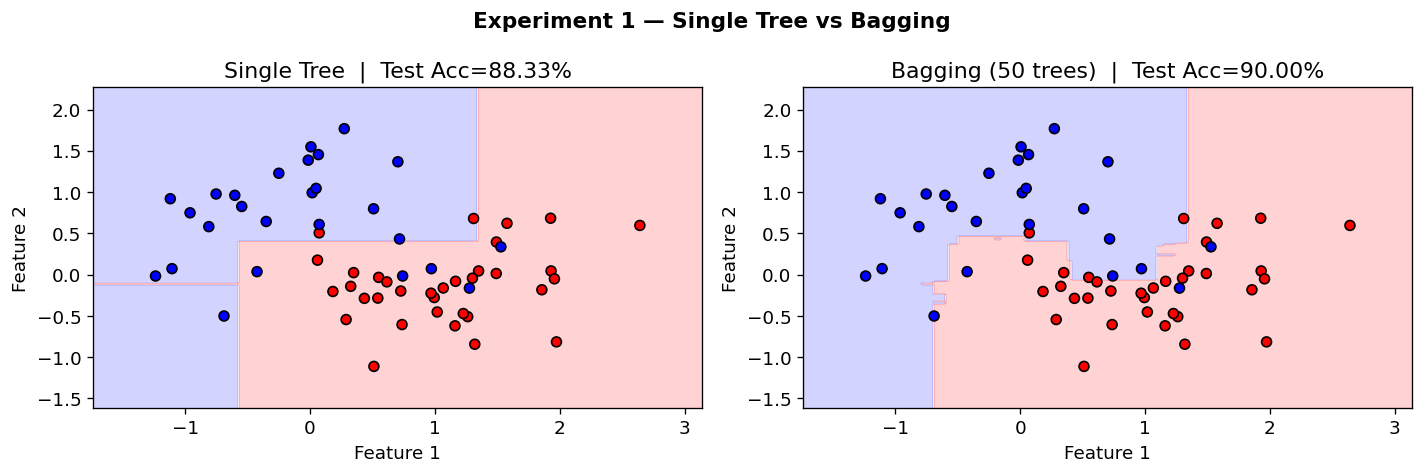

Single Tree Accuracy : 88.33%
Bagging Accuracy     : 90.00%

 EXPERIMENT 2 — Effect of n_estimators


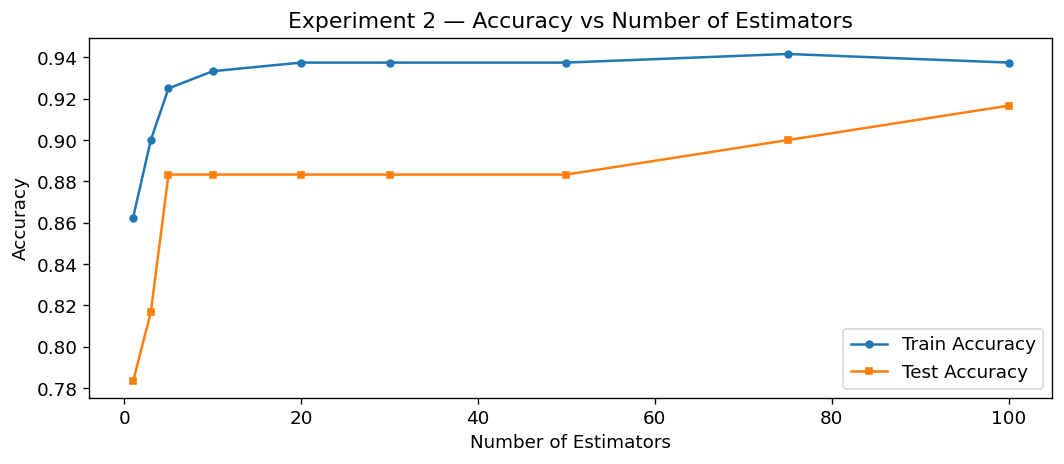

 EXPERIMENT 3 — Voting Classifier (Breast Cancer)


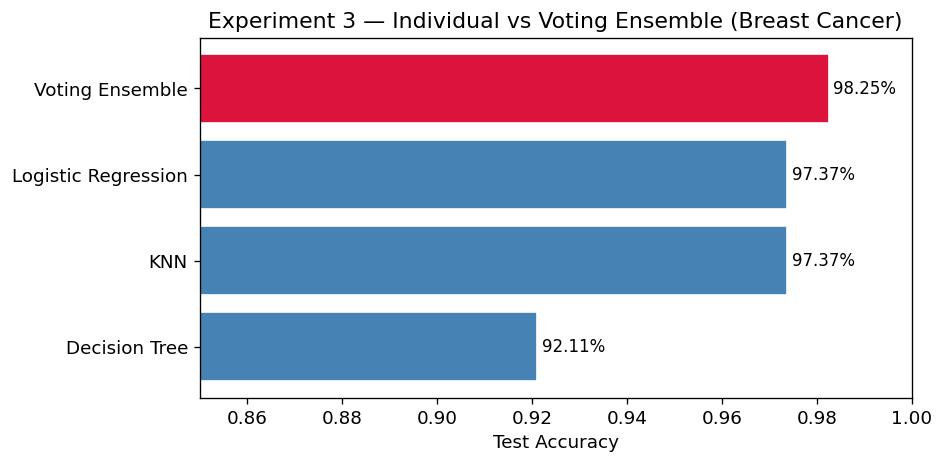

Decision Tree         : 92.11%
KNN                   : 97.37%
Logistic Regression   : 97.37%
Voting Ensemble       : 98.25%

 EXPERIMENT 4 — Bagging Classifier Full Evaluation
Test Accuracy : 93.86%

              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



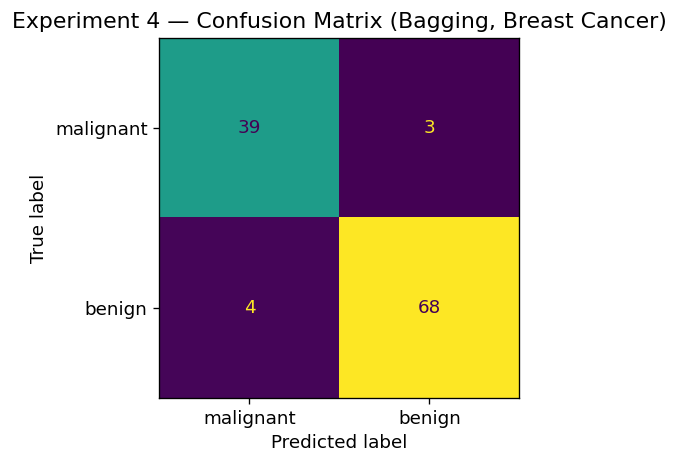

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage.supervised_learning.ensemble_methods import (
    BaggingClassifier, BaggingRegressor, VotingClassifier
)
from mlpackage.supervised_learning.decision_tree import DecisionTree
from mlpackage.supervised_learning.knn import KNN
from mlpackage.supervised_learning.logistic_regression import LogisticRegression

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── Helper ────────────────────────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="bwr")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


# ── 1. Single Tree vs Bagging ─────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — Single Tree vs Bagging (Moons)")
print("=" * 55)

X_moon, y_moon = make_moons(n_samples=300, noise=0.3, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_moon, y_moon, test_size=0.2, random_state=42)

single_tree = DecisionTree(max_depth=5, random_state=0)
bagging     = BaggingClassifier(DecisionTree(max_depth=5), n_estimators=50, random_state=42)
single_tree.fit(X_tr, y_tr)
bagging.fit(X_tr, y_tr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_decision_boundary(single_tree, X_te, y_te, axes[0],
    f"Single Tree  |  Test Acc={single_tree.score(X_te, y_te):.2%}")
plot_decision_boundary(bagging, X_te, y_te, axes[1],
    f"Bagging (50 trees)  |  Test Acc={bagging.score(X_te, y_te):.2%}")
plt.suptitle("Experiment 1 — Single Tree vs Bagging", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Single Tree Accuracy : {single_tree.score(X_te, y_te):.2%}")
print(f"Bagging Accuracy     : {bagging.score(X_te, y_te):.2%}\n")


# ── 2. Effect of n_estimators ─────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Effect of n_estimators")
print("=" * 55)

n_range = [1, 3, 5, 10, 20, 30, 50, 75, 100]
train_accs, test_accs = [], []
for n in n_range:
    clf = BaggingClassifier(DecisionTree(max_depth=5), n_estimators=n, random_state=42)
    clf.fit(X_tr, y_tr)
    train_accs.append(clf.score(X_tr, y_tr))
    test_accs.append(clf.score(X_te, y_te))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_range, train_accs, marker="o", markersize=4, label="Train Accuracy")
ax.plot(n_range, test_accs,  marker="s", markersize=4, label="Test Accuracy")
ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Accuracy")
ax.set_title("Experiment 2 — Accuracy vs Number of Estimators")
ax.legend()
plt.tight_layout()
plt.show()


# ── 3. Voting Classifier — Model Comparison ───────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — Voting Classifier (Breast Cancer)")
print("=" * 55)

data = load_breast_cancer()
X_b, y_b = data.data, data.target
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)
sc = StandardScaler()
X_tr_bs = sc.fit_transform(X_tr_b)
X_te_bs  = sc.transform(X_te_b)

dt_clf  = DecisionTree(max_depth=5, random_state=0)
knn_clf = KNN(k=7)
lr_clf  = LogisticRegression(learning_rate=0.1, n_iters=500)
voting  = VotingClassifier([
    ("dt",  DecisionTree(max_depth=5, random_state=0)),
    ("knn", KNN(k=7)),
    ("lr",  LogisticRegression(learning_rate=0.1, n_iters=500)),
], voting="hard")

results = {}
for name, clf in [("Decision Tree", dt_clf), ("KNN", knn_clf),
                  ("Logistic Regression", lr_clf), ("Voting Ensemble", voting)]:
    clf.fit(X_tr_bs, y_tr_b)
    results[name] = clf.score(X_te_bs, y_te_b)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["steelblue", "steelblue", "steelblue", "crimson"]
bars = ax.barh(list(results.keys()), list(results.values()),
               color=colors, edgecolor="white")
ax.set_xlabel("Test Accuracy")
ax.set_title("Experiment 3 — Individual vs Voting Ensemble (Breast Cancer)")
ax.set_xlim(0.85, 1.0)
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.2%}", va="center", fontsize=10)
plt.tight_layout()
plt.show()
for name, acc in results.items():
    print(f"{name:<22}: {acc:.2%}")


# ── 4. Bagging Classifier — Full Evaluation ───────────────────────────────────
print("\n" + "=" * 55)
print(" EXPERIMENT 4 — Bagging Classifier Full Evaluation")
print("=" * 55)

bag_final = BaggingClassifier(DecisionTree(max_depth=8), n_estimators=100, random_state=42)
bag_final.fit(X_tr_bs, y_tr_b)
y_pred = bag_final.predict(X_te_bs)

print(f"Test Accuracy : {bag_final.score(X_te_bs, y_te_b):.2%}\n")
print(classification_report(y_te_b, y_pred, target_names=data.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te_b, y_pred),
                       display_labels=data.target_names).plot(ax=ax, colorbar=False)
ax.set_title("Experiment 4 — Confusion Matrix (Bagging, Breast Cancer)")
plt.tight_layout()
plt.show()